<center> <h1> Netflix Catalog: Cleaning and Exploratory Analysis</h1> </center>

Netflix is one of the most popular media and video streaming platforms. They have over 10000 movies or tv shows available on their platform, as of mid-2021, they had over 222M Subscribers globally.

## Dataset

Dataset is publicly available on kaggle: <br>
https://www.kaggle.com/datasets/shivamb/netflix-shows

## Objective

Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries.

## Data Dictionary

**show_id:** Unique ID for every Movie / Tv Show <br>
**type:** Identifier - A Movie or TV Show<br>
**title:** Title of the Movie / Tv Show<br>
**director:** Director of the Movie<br>
**cast:** Actors involved in the movie/show<br>
**country:** Country where the movie/show was produced<br>
**date_added:** Date it was added on Netflix <br>
**release_year:** Actual Release year of the movie/show <br>
**rating:** TV Rating of the movie/show <br>
**duration:** Total Duration - in minutes or number of seasons <br>
**listed_in:** Genre <br>
**description:** The summary description <br>

## Basic EDA
Basic EDA to determine data cleaning actions need to be taken.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from collections import namedtuple

In [4]:
%matplotlib inline

In [5]:
pd.set_option('display.max_colwidth', None)

In [6]:
pd.set_option('display.max_rows', 500)
# pd.set_option('display.max_rows', None)

In [7]:
df = pd.read_csv("nflx.csv")

In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


#### `description` column needs NLP to be able to use it in analysis; will drop it for this analysis - earlier on - to reduce memory footprint.

In [9]:
df.shape

(8807, 12)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


#### Columns containing null values: `director`, `cast`, `country`, `date_added`, `rating` and `duration` 
Null value treatment to be done accordingly based on percantage of value missing, type of column, etc.

### Check for empty strings in columns.

In [13]:
for col in df.columns:
    if not pd.api.types.is_string_dtype(df[col]):
        continue
    empty_count = len(df.loc[df[col].str.strip() == ''])
    print(f"col: {col}, #empty_count={empty_count}")

col: show_id, #empty_count=0
col: type, #empty_count=0
col: title, #empty_count=0
col: director, #empty_count=0
col: cast, #empty_count=0
col: country, #empty_count=0
col: date_added, #empty_count=0
col: rating, #empty_count=0
col: duration, #empty_count=0
col: listed_in, #empty_count=0
col: description, #empty_count=0


### Check if any row is duplicated?

In [14]:
len(df[df.duplicated(keep='first')])

0

No rows are entirely duplicated.

In [15]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


Strange that we see that for `description` column, there's a description repeated 4 times. Let's identify these 4 rows

In [16]:
df[df["description"] == "Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
236,s237,Movie,Boomika,Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madhuri, Pavel Navageethan, Avantika Vandanapu",NaN,"August 23, 2021",2021,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."
237,s238,Movie,Boomika (Hindi),Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madhuri, Pavel Navageethan, Avantika Vandanapu",NaN,"August 23, 2021",2021,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."
238,s239,Movie,Boomika (Malayalam),Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madhuri, Pavel Navageethan, Avantika Vandanapu",NaN,"August 23, 2021",2021,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."
239,s240,Movie,Boomika (Telugu),Rathindran R Prasad,"Aishwarya Rajesh, Vidhu, Surya Ganapathy, Madhuri, Pavel Navageethan, Avantika Vandanapu",NaN,"August 23, 2021",2021,TV-14,122 min,"Horror Movies, International Movies, Thrillers","Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."


These 4 entries represent 4 different languages for the same movie and convey same information in other columns apart from maybe `date_added` column in some instances. <br>
**We will drop the shows - s238, s239, s240**

Checking if there are more such cases where description is same but movie/tv-show titles only contain language as an addition.

In [17]:
description_duplicated_df = df[df.duplicated(subset=['description'], keep=False)]
description_duplicated_df.groupby('description', group_keys=True).apply(
    lambda x: pd.DataFrame(data={'show_id': x['show_id'], 'title': x['title'], 'type': x['type'], 'date_added': x['date_added'], 'country': x['country']}),
    include_groups=False  # need to set in pandas 2.2.0 to avoid printing deprecation warning, this should be default behavior in future - Basically we don't want description column
                          # in each grouped dataframe  
)

show_id  \
description                                                                                                                                                              
A budding politician has devious plans to rise in the ranks — until an unexpected new presence begins to interfere with his every crooked move.           78       s79   
                                                                                                                                                          79       s80   
A scheming matriarch plots to cut off her disabled stepson and his wife from the family fortune, creating a division within the clan.                     2969   s2970   
                                                                                                                                                          7022   s7023   
A surly septuagenarian gets another chance at her 20s after having her photo snapped at a studio that magically takes 50 years off her life.              3492   s3493   
                                                                                                                                                          3493   s3494   
                                                                                                                                                          3516   s3517   
A young Han Solo tries to settle an old score with the help of his new buddy Chewbacca, a crew of space smugglers and a cunning old friend.               8051   s8052   
                                                                                                                                                          8052   s8053   
After devastating terror attacks in Norway, a young survivor, grieving families and the country rally for justice and healing. Based on a true story.     4522   s4523   
                                                                                                                                                          5965   s5966   
After growing up enduring criticism from his father, a young man finds his world shaken upon learning he was switched at birth with a millionaire’s son.  2840   s2841   
                                                                                                                                                          2873   s2874   
An affable, newly appointed college warden proves to be no ordinary man when an old enemy resurfaces and exposes his complicated, violent past.           3933   s3934   
                                                                                                                                                          3939   s3940   
An aspiring musician battles age-old caste divides to be able to learn the art of a classical instrument from a traditionalist, veteran percussionist.    3932   s3933   
                                                                                                                                                          4061   s4062   
As a blind librarian, dispirited cricketer and desolate psychiatrist each seek retribution and release, their lives overlap under eerie influences.       1652   s1653   
                                                                                                                                                          1653   s1654   
As a psychology professor faces Alzheimer's, his daughter and her three close female friends experience romance, marriage, heartbreak and tragedy.        3996   s3997   
                                                                                                                                                          5964   s5965   
As a series of murders hit close to home, a video game designer with post-traumatic stress must confront her demons, or risk becoming their victim.       3568   s3569   
                                                                               

In general, for each description group above we will retain first show_id.

In [18]:
show_ids_to_drop = set(
    df.loc[df.duplicated(subset='description', keep='first'), 'show_id']
)
print(show_ids_to_drop)

{'s2874', 's3570', 's1654', 's2336', 's7090', 's853', 's80', 's238', 's3494', 's240', 's239', 's6025', 's3394', 's6450', 's852', 's6530', 's7560', 's8053', 's7023', 's8023', 's8174', 's6706', 's3517', 's8361', 's5965', 's7091', 's1987', 's5966', 's3940', 's5967', 's7650', 's4062'}


In [182]:
# all_show_ids_where_desc_duplicated = set(description_duplicated_df['show_id'].unique())
# first_show_ids_where_desc_duplicated = set(df[~df.duplicated(subset=['description'], keep='first')]['show_id'].unique())
# show_ids_to_drop = all_show_ids_where_desc_duplicated - first_show_ids_where_desc_duplicated
# show_ids_to_drop

In [20]:
len(show_ids_to_drop)

32

In [21]:
show_ids_to_drop = list(show_ids_to_drop)

#### Above analysis of rows where description is duplicated and possibility of having only language difference in titles - doesn't include cases where description is null - but as shown below this column doesn't contain null values anyway.

In [22]:
# len(df[df['description'] == ''])

In [23]:
len(df[df["description"].isna()])

0

No null values in description column.

### Check for columns containing nested values

In [24]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [25]:
df["director"].value_counts()

director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Peter Hewitt                1
Mozez Singh                 1
Name: count, Length: 4528, dtype: int64

In [26]:
df["cast"].value_counts()

cast
David Attenborough                                                                                                                                             19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                                                        14
Samuel West                                                                                                                                                    10
Jeff Dunham                                                                                                                                                     7
David Spade, London Hughes, Fortune Feimster                                                                                                                    6
                                                                                                                                                               ..
Ali Suliman, Saleh Bakr

In [27]:
df["country"].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [28]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [29]:
df["listed_in"].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

In [30]:
df["duration"].value_counts()

duration
1 Season      1793
2 Seasons      425
3 Seasons      199
90 min         152
94 min         146
97 min         146
93 min         146
91 min         144
95 min         137
96 min         130
92 min         129
102 min        122
98 min         120
99 min         118
88 min         116
101 min        116
103 min        114
106 min        111
100 min        108
89 min         106
104 min        104
86 min         103
105 min        101
87 min         101
107 min         98
110 min         97
4 Seasons       95
108 min         87
116 min         80
112 min         74
85 min          73
113 min         69
109 min         69
111 min         68
84 min          67
5 Seasons       65
83 min          65
118 min         65
119 min         63
81 min          62
115 min         61
117 min         61
114 min         56
120 min         56
121 min         54
124 min         52
82 min          52
127 min         48
122 min         45
78 min          45
123 min         44
126 min         44
80 

#### Columns that require un-nesting or 'explode': `country`, `director`, `cast`, `listed_in`

We see `rating` column has 3 entries which is should belong to `duration` column: '74 min', '84 min' and '66 min'. Printing these rows:

In [31]:
df[~df['rating'].isna() & df['rating'].str.contains('min')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, giving dogs drugs, email fights, teachers and more in a live performance from Washington, D.C."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,"Emmy-winning comedy writer Louis C.K. brings his caustic wit to Milwaukee, offering up his unique and uncensored take on sex, parenting and more."
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,"The comic puts his trademark hilarious/thought-provoking spin on finding a bat in his kitchen, seeing rats having sex, Boston accents and dead pets."


#### For show_ids **s5542**, **s5795** and **s5814** need to move `rating` column values to duration and populate `rating` with null and treat missing values later.

### Data type checks

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


#### These columns can be converted to category type: `type`, `rating`
#### `listed_in` can also be converted to category after exploding this column.

#### `date_added` can be converted to datetime type. Also, we can extract more features from this column - year, month, week, day-of-week, day

#### `duration` can be converted to `int` type after retaining only numeric values and separating dataframe into tv-shows and movies.

<div style="background-color: black"><center>&#x2728; &#x2728; &#x2728;<center></div>

## Data Cleaning / pre-processing

Let's keep the original dataset in a variable after ensuring there's a unique identifier for each row and identifier is not null anywhere.

In [33]:
len(df[df.duplicated(subset=['show_id'])])

0

In [34]:
len(df[df['show_id'].isna()])

0

Thus, each row has a unique non-null identifier. `df` is our original dataset.

In [35]:
dfc = df.copy()

### Drop rows / columns

#### Drop description column

In [36]:
dfc.drop('description', axis=1, inplace=True)

In [37]:
dfc.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')

#### Filter out required shows

We will exclude the unwanted rows identified earlier while exploring data where description was same - but differences only in language.

In [38]:
len(dfc)

8807

In [39]:
dfc = dfc[~dfc['show_id'].isin(show_ids_to_drop)]

In [40]:
len(dfc)

8775

We dropped 32 show_ids.

### Fix 3 show_ids where `duration` values are present in `rating` column instead. 

In [41]:
dfc.loc[dfc['show_id'].isin(['s5542', 's5795', 's5814']), 'duration'] = dfc.loc[dfc['show_id'].isin(['s5542', 's5795', 's5814']), 'rating']
dfc.loc[dfc['show_id'].isin(['s5542', 's5795', 's5814']), 'rating'] = np.nan
dfc.loc[dfc['show_id'].isin(['s5542', 's5795', 's5814'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,NaN,74 min,Movies
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NaN,84 min,Movies
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NaN,66 min,Movies


### Strip columns of whitespaces

In [42]:
for col in dfc.columns:
    if not pd.api.types.is_string_dtype(dfc[col]):
        continue
    dfc[col] = dfc[col].str.strip()
    print(f"Stripped col: {col}")

Stripped col: show_id
Stripped col: type
Stripped col: title
Stripped col: director
Stripped col: cast
Stripped col: country
Stripped col: date_added
Stripped col: rating
Stripped col: duration
Stripped col: listed_in


### Explode columns: `country`, `director`, `cast`, `listed_in`

#### Explode `country` column

In [43]:
dfc['country'].head(10)

0                                                            United States
1                                                             South Africa
2                                                                      NaN
3                                                                      NaN
4                                                                    India
5                                                                      NaN
6                                                                      NaN
7    United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia
8                                                           United Kingdom
9                                                            United States
Name: country, dtype: str

In [44]:
dfc.iloc[7]

show_id                                                                                                                      s8
type                                                                                                                      Movie
title                                                                                                                   Sankofa
director                                                                                                           Haile Gerima
cast            Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra Duah, Nick Medley, Mutabaruka, Afemo Omilami, Reggie Carter, Mzuri
country                                                   United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia
date_added                                                                                                   September 24, 2021
release_year                                                                                            

In [45]:
dfc['country'] = dfc['country'].str.split(',')

In [46]:
dfc['country'].value_counts()

country
[United States]                                       2816
[India]                                                963
[United Kingdom]                                       419
[Japan]                                                242
[South Korea]                                          199
                                                      ... 
[Russia,  Spain]                                         1
[Croatia,  Slovenia,  Serbia,  Montenegro]               1
[Japan,  Canada]                                         1
[United States,  France,  South Korea,  Indonesia]       1
[United Arab Emirates,  Jordan]                          1
Name: count, Length: 747, dtype: int64

In [47]:
dfc['country'].head(10)

0                                                                 [United States]
1                                                                  [South Africa]
2                                                                             NaN
3                                                                             NaN
4                                                                         [India]
5                                                                             NaN
6                                                                             NaN
7    [United States,  Ghana,  Burkina Faso,  United Kingdom,  Germany,  Ethiopia]
8                                                                [United Kingdom]
9                                                                 [United States]
Name: country, dtype: object

In [48]:
# dfc['country'] = dfc['country'].apply(lambda countries: [country.strip() for country in countries] if isinstance(countries, list) else [])

In [49]:
dfc = dfc.explode('country')

In [50]:
dfc['country'].value_counts()

country
United States            3208
India                     998
United Kingdom            628
 United States            478
Canada                    271
Japan                     256
France                    211
South Korea               211
 France                   181
Spain                     181
 United Kingdom           178
 Canada                   174
Mexico                    134
 Germany                  123
Australia                 117
Egypt                     112
Turkey                    110
Germany                   103
China                     100
Nigeria                    96
Taiwan                     85
Indonesia                  85
Brazil                     84
Philippines                80
Hong Kong                  79
Argentina                  75
 Belgium                   72
Italy                      67
Thailand                   65
 China                     62
 Japan                     59
 Spain                     51
 Australia                 43
So

In [51]:
dfc['country'] = dfc['country'].str.strip()

In [52]:
dfc['country'].value_counts(dropna=False)

country
United States           3686
India                   1036
NaN                      819
United Kingdom           806
Canada                   445
France                   392
Japan                    315
Spain                    232
South Korea              231
Germany                  226
Mexico                   169
China                    162
Australia                160
Egypt                    117
Turkey                   111
Hong Kong                105
Nigeria                  103
Italy                    100
Brazil                    97
Belgium                   90
Argentina                 90
Indonesia                 90
Taiwan                    89
Philippines               83
Thailand                  70
South Africa              62
Colombia                  51
Netherlands               50
Denmark                   48
Ireland                   46
Sweden                    42
Singapore                 41
Poland                    41
United Arab Emirates      37
New Ze

From above value counts table, we see there are 7 rows where country column consists only of white-spaces. let's filter out these show_ids in the original df and check:

In [53]:
empty_country_show_ids = dfc.loc[dfc['country'].str.strip() == '', 'show_id']
empty_country_show_ids

193      s194
365      s366
1192    s1193
2224    s2225
4653    s4654
5925    s5926
7007    s7008
Name: show_id, dtype: str

In [54]:
df.loc[df['show_id'].isin(empty_country_show_ids)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
193,s194,TV Show,D.P.,NaN,"Jung Hae-in, Koo Kyo-hwan, Kim Sung-kyun, Son Suk-ku",", South Korea","August 27, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas",A young private’s assignment to capture army deserters reveals the painful reality endured by each enlistee during his compulsory call of duty.
365,s366,Movie,Eyes of a Thief,Najwa Najjar,"Khaled Abol El Naga, Souad Massi, Suhail Haddad, Malak Ermileh, Maisa Abd Elhadi, Walid Abdul Salam, Nisreen Faour, Areen Omari",", France, Algeria","July 30, 2021",2014,TV-14,103 min,"Dramas, Independent Movies, International Movies","After a decade in prison, a Palestinian man with a dark secret returns to the West Bank and searches for the daughter he lost long ago."
1192,s1193,Movie,The Present,Farah Nabulsi,"Saleh Bakri, Maryam Kanj, Maryam Kamiel Basha, Ameer Khlawe, Ala' Hanani, Malak Abu Ghraibeh, Karam Elayyan, Leila Mouammar, Angie Saba","United Kingdom,","March 18, 2021",2020,TV-MA,24 min,"Dramas, International Movies","Yusuf and his daughter set out to buy his wife an anniversary gift, a gesture demanding much patience and negotiation skills in the West Bank."
2224,s2225,Movie,Funan,Denis Do,"Bérénice Bejo, Louis Garrel, Colette Kieffer, Aude-Laurence Clermont Biver, Brice Montagne, Franck Sasonoff, Hervé Sogne, Maxime Baudoin, Tom Trouffier, Lila Lacombe, Céline Ronté, Emilie Marié, Thierry Jahn","France, Belgium, Luxembourg, Cambodia,","July 18, 2020",2018,TV-14,87 min,"Dramas, International Movies","Separated from their young son during the brutal Khmer Rouge revolution, a couple must find ways to endure while searching for their child."
4653,s4654,Movie,City of Joy,Madeleine Gavin,NaN,"United States,","September 7, 2018",2018,TV-MA,77 min,Documentaries,"Women who've been sexually brutalized in war-torn Congo begin to heal at City of Joy, a center that helps them regain a sense of self and empowerment."
5925,s5926,Movie,Virunga,Orlando von Einsiedel,NaN,"United Kingdom,","November 7, 2014",2014,TV-MA,100 min,"Documentaries, International Movies",The Oscar-nominated true story of the rangers risking their lives to save Africa's most precious national park and its endangered gorillas.
7007,s7008,Movie,Hotel Pacific,Janusz Majewski,"Marek Kondrat, Roman Wilhelmi, Roman Skamene, Čestmír Řanda, Michał Pawlicki, Martin Hron, Stanisława Celińska, Joanna Kasperska, Jaroslava Schallerová","Poland,","October 1, 2019",1975,TV-MA,96 min,"Classic Movies, Dramas, International Movies",A motivated teen strives to rise from dishwasher to waiter at a luxury hotel only to tread in the abusive tide of its workplace hierarchy.


We see a ',' character either at beginning or the end in the `country` column - so for these cases we obtained unwanted rows as well with only whitespaces in `country` column.

We will remove such rows.

In [55]:
len(dfc)

10814

In [56]:
dfc = dfc.loc[dfc['country'].str.strip() != '']

In [57]:
len(dfc)

10807

#### Strip `,` from nested columns

To avoid same issue as with `country` column where we obtained unwanted rows with empty string `country` column after exploding, we will strip `,` from other 3 nested columns beforehand.

In [58]:
dfc['director'] = dfc['director'].str.strip(',')
dfc['cast'] = dfc['cast'].str.strip(',')
dfc['listed_in'] = dfc['listed_in'].str.strip(',')

#### Explode `director` column

In [59]:
len(dfc)

10807

In [60]:
dfc['director'] = dfc['director'].str.split(',')

In [61]:
dfc['director'].value_counts(dropna=False)

director
NaN                          2960
[Rajiv Chilaka]                19
[Steven Spielberg]             18
[Martin Scorsese]              18
[Raúl Campos,  Jan Suter]      18
                             ... 
[James Brown]                   1
[Mu Chu]                        1
[Chandra Prakash Dwivedi]       1
[Peter Hewitt]                  1
[Mozez Singh]                   1
Name: count, Length: 4528, dtype: int64

In [62]:
dfc = dfc.explode('director')
dfc['director'] = dfc['director'].str.strip()

In [63]:
dfc['director'].value_counts(dropna=False)

director
NaN                        2960
Rajiv Chilaka                22
Jan Suter                    21
Raúl Campos                  19
Steven Spielberg             18
                           ... 
James Brown                   1
Mu Chu                        1
Chandra Prakash Dwivedi       1
Peter Hewitt                  1
Mozez Singh                   1
Name: count, Length: 4993, dtype: int64

In [64]:
len(dfc.loc[dfc['director'].str.strip() == ''])

0

In [65]:
len(dfc)

11874

#### Explode `cast` column

In [66]:
dfc['cast'] = dfc['cast'].str.split(',')

In [67]:
dfc = dfc.explode('cast')

In [68]:
dfc['cast'] = dfc['cast'].str.strip()

In [69]:
dfc['cast'].value_counts(dropna=False)

cast
NaN                      1185
Alfred Molina              85
Liam Neeson                82
John Krasinski             67
Salma Hayek                66
                         ... 
Ryan Newman                 1
Raaghav Chanana             1
Malkeet Rauni               1
Anita Shabdish              1
Chittaranjan Tripathy       1
Name: count, Length: 36431, dtype: int64

In [70]:
len(dfc)

89102

#### Explode `listed_in` column

In [71]:
dfc['listed_in'] = dfc['listed_in'].str.split(',')
dfc = dfc.explode('listed_in')
dfc['listed_in'] = dfc['listed_in'].str.strip()

In [72]:
dfc['listed_in'].value_counts(dropna=False)

listed_in
Dramas                          29693
International Movies            28055
Comedies                        20754
International TV Shows          12793
Action & Adventure              12168
Independent Movies               9818
Children & Family Movies         9753
TV Dramas                        8890
Thrillers                        7030
Romantic Movies                  6411
TV Comedies                      4963
Crime TV Shows                   4733
Kids' TV                         4565
Horror Movies                    4531
Sci-Fi & Fantasy                 4029
Romantic TV Shows                3049
Music & Musicals                 3026
Documentaries                    2407
Anime Series                     2313
TV Action & Adventure            2288
Spanish-Language TV Shows        2088
British TV Shows                 1808
Sports Movies                    1531
Classic Movies                   1434
TV Mysteries                     1281
Korean TV Shows                  1122
Cu

In [73]:
len(dfc)

201228

### Null-Value Detection

In [74]:
dfc.info()

<class 'pandas.DataFrame'>
Index: 201228 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   show_id       201228 non-null  str  
 1   type          201228 non-null  str  
 2   title         201228 non-null  str  
 3   director      150740 non-null  str  
 4   cast          199093 non-null  str  
 5   country       189494 non-null  str  
 6   date_added    201070 non-null  str  
 7   release_year  201228 non-null  int64
 8   rating        201158 non-null  str  
 9   duration      201228 non-null  str  
 10  listed_in     201228 non-null  str  
dtypes: int64(1), str(10)
memory usage: 18.4 MB


In [75]:
for col in dfc.columns:
    null_count = len(dfc.loc[dfc[col].isna()])
    percentage_null = round(null_count / len(dfc) * 100, 2)
    print(f"For col {col}, null_count: {null_count}, percentage_null: {percentage_null}")

For col show_id, null_count: 0, percentage_null: 0.0
For col type, null_count: 0, percentage_null: 0.0
For col title, null_count: 0, percentage_null: 0.0
For col director, null_count: 50488, percentage_null: 25.09
For col cast, null_count: 2135, percentage_null: 1.06
For col country, null_count: 11734, percentage_null: 5.83
For col date_added, null_count: 158, percentage_null: 0.08
For col release_year, null_count: 0, percentage_null: 0.0
For col rating, null_count: 70, percentage_null: 0.03
For col duration, null_count: 0, percentage_null: 0.0
For col listed_in, null_count: 0, percentage_null: 0.0


#### Above null counts are from a relatively cleaned dataframe and also it's exploded, so let's do a null count on the original dataframe to have better idea. 

In [76]:
for col in df.columns:
    null_count = len(df.loc[df[col].isna()])
    percentage_null = round(null_count / len(df) * 100, 2)
    print(f"For col {col}, null_count: {null_count}, percentage_null: {percentage_null}")

For col show_id, null_count: 0, percentage_null: 0.0
For col type, null_count: 0, percentage_null: 0.0
For col title, null_count: 0, percentage_null: 0.0
For col director, null_count: 2634, percentage_null: 29.91
For col cast, null_count: 825, percentage_null: 9.37
For col country, null_count: 831, percentage_null: 9.44
For col date_added, null_count: 10, percentage_null: 0.11
For col release_year, null_count: 0, percentage_null: 0.0
For col rating, null_count: 4, percentage_null: 0.05
For col duration, null_count: 3, percentage_null: 0.03
For col listed_in, null_count: 0, percentage_null: 0.0
For col description, null_count: 0, percentage_null: 0.0


#### Columns with null values: `director`, `country`, `cast`, `date_added`, `rating`, `duration`

#### Treat null values: `director` column

29.91 % of director values in original df is null. It's still probably fine to impute the values - atleast missing percentage doesn't excceed 30%

Reference: https://stackoverflow.com/questions/19966018/filling-missing-values-by-mean-in-each-group

In [77]:
dfc['director'].value_counts(dropna=False)

director
NaN                       50488
Martin Scorsese             419
Youssef Chahine             409
Cathy Garcia-Molina         356
Steven Spielberg            355
                          ...  
Rebecca Harrison              1
Milla Harrison-Hansley        1
Alicky Sussman                1
Anatole Litvak                1
Storm Theunissen              1
Name: count, Length: 4993, dtype: int64

Above frequency count is from exploded df, to get better idea of missing 'director' values, keep only unique combinations of (show_id, director) to avoid miscounting.

In [78]:
unique_show_id_director_df = dfc.loc[~dfc.duplicated(subset=['show_id', 'director'], keep='first')]
unique_show_id_director_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,Sami Bouajila,NaN,"September 24, 2021",2021,TV-MA,1 Season,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,Docuseries
4,s5,TV Show,Kota Factory,NaN,Mayur More,India,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows


In [79]:
len(unique_show_id_director_df)

9579

In [80]:
unique_show_id_director_df['director'].value_counts(dropna=False)

director
NaN                        2626
Rajiv Chilaka                22
Jan Suter                    21
Raúl Campos                  19
Suhas Kadav                  16
                           ... 
Mu Chu                        1
Chandra Prakash Dwivedi       1
Majid Al Ansari               1
Peter Hewitt                  1
Mozez Singh                   1
Name: count, Length: 4993, dtype: int64

In [81]:
len(dfc)

201228

Creating a separate copy of `dfc` dataframe, will impute the values in `director` column - will continue using `dfc` dataframe in case imputation introduces skew.

In [82]:
dfc2 = dfc.copy()

In [83]:
def calculate_mode(x: pd.Series):
    if x.isna().all():
        return np.nan
    
    return x.mode().iloc[0]

In [84]:
dfc2['director'] = dfc2['director'].fillna(dfc2.groupby(['country', 'listed_in', 'type'])['director'].transform(calculate_mode))
#dfc2['director'] = dfc2.groupby(['country', 'listed_in'])['director'].transform(lambda x: x.fillna(x.mode()))

In [85]:
dfc.loc[~dfc.duplicated(subset=['show_id', 'director'], keep='first')]['director'].value_counts(dropna=False)

director
NaN                        2626
Rajiv Chilaka                22
Jan Suter                    21
Raúl Campos                  19
Suhas Kadav                  16
                           ... 
Mu Chu                        1
Chandra Prakash Dwivedi       1
Majid Al Ansari               1
Peter Hewitt                  1
Mozez Singh                   1
Name: count, Length: 4993, dtype: int64

In [86]:
dfc2.loc[~dfc2.duplicated(subset=['show_id', 'director'], keep='first')]['director'].value_counts(dropna=False)

director
NaN                        991
Danny Cannon               326
Noam Murro                 279
Thomas Astruc              269
David Schalko              249
                          ... 
Mu Chu                       1
Chandra Prakash Dwivedi      1
Majid Al Ansari              1
Peter Hewitt                 1
Mozez Singh                  1
Name: count, Length: 4993, dtype: int64

In [87]:
director_counts = dfc2.loc[~dfc2.duplicated(subset=['show_id', 'director'], keep='first')]['director'].value_counts(dropna=False).reset_index()
director_counts

,director,count
0,NaN,991
1,Danny Cannon,326
2,Noam Murro,279
3,Thomas Astruc,269
4,David Schalko,249
...,...,...
4988,Mu Chu,1
4989,Chandra Prakash Dwivedi,1
4990,Majid Al Ansari,1
4991,Peter Hewitt,1


#### Although null director values reduced from 2626 to 991 after imputation, we see a skew has been introduced - we have now a few set of directors assigned to a lot of shows. We will disregard this imputation and continue to work with `dfc` dataframe, it should not impact heavily on our analysis.

#### As for other columns with null values, we will skip imputation as well, as percentage of null values is less than 10% if not even less.

### Extract features from `date_added` column: `date_added_year`, `date_added_month`, `date_added_day`, `date_added_week`, `date_added_dayofweek`

In [88]:
dfc['date_added'].dtype

<StringDtype(storage='python', na_value=nan)>

In [89]:
dfc['date_added'] = pd.to_datetime(dfc['date_added'])

In [90]:
dfc['date_added'].dtype

dtype('<M8[us]')

In [91]:
dfc.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas


In [92]:
dfc['date_added_year'] = dfc['date_added'].dt.year
dfc['date_added_month'] = dfc['date_added'].dt.month
dfc['date_added_day'] = dfc['date_added'].dt.day

dfc['date_added_week'] = dfc['date_added'].dt.isocalendar().week
dfc['date_added_dayofweek'] = dfc['date_added'].dt.dayofweek # 0 = Monday, 6 = Sunday

In [93]:
dfc.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,date_added_week,date_added_dayofweek
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021.0,9.0,25.0,38,5.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,2021.0,9.0,24.0,38,4.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,2021.0,9.0,24.0,38,4.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,2021.0,9.0,24.0,38,4.0
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,2021.0,9.0,24.0,38,4.0


In [94]:
dfc.dtypes

show_id                            str
type                               str
title                              str
director                           str
cast                               str
country                            str
date_added              datetime64[us]
release_year                     int64
rating                             str
duration                           str
listed_in                          str
date_added_year                float64
date_added_month               float64
date_added_day                 float64
date_added_week                 UInt32
date_added_dayofweek           float64
dtype: object

### Create different dataframes for TV shows and Movies.

In [95]:
dfc['type'].value_counts(dropna=False)

type
Movie      145234
TV Show     55994
Name: count, dtype: int64

In [96]:
df_tv = dfc.loc[dfc['type'] == 'TV Show'].copy()
df_mov = dfc.loc[dfc['type'] == 'Movie'].copy()

In [97]:
df_tv.shape[0]

55994

In [98]:
df_mov.shape[0]

145234

In [99]:
df_tv.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,date_added_week,date_added_dayofweek
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,2021.0,9.0,24.0,38,4.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,2021.0,9.0,24.0,38,4.0
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,2021.0,9.0,24.0,38,4.0


In [100]:
df_mov.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,date_added_week,date_added_dayofweek
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021.0,9.0,25.0,38,5.0
6,s7,Movie,My Little Pony: A New Generation,Robert Cullen,Vanessa Hudgens,NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,2021.0,9.0,24.0,38,4.0
6,s7,Movie,My Little Pony: A New Generation,Robert Cullen,Kimiko Glenn,NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,2021.0,9.0,24.0,38,4.0


### Clean `duration` column in `df_tv`, `df_mov` dataframes

#### Clean in `df_tv`

In [101]:
df_tv['duration'].value_counts(dropna=False)

duration
1 Season      34995
2 Seasons      9559
3 Seasons      4970
4 Seasons      2134
5 Seasons      1698
7 Seasons       843
6 Seasons       633
8 Seasons       286
9 Seasons       257
10 Seasons      220
13 Seasons      132
12 Seasons      111
15 Seasons       96
17 Seasons       30
11 Seasons       30
Name: count, dtype: int64

In [102]:
df_tv['duration_in_seasons'] = df_tv['duration'].str.split(' ').str[0]

In [103]:
df_tv.loc[~df_tv.duplicated(subset=['show_id'], keep='first'), 'duration_in_seasons'].value_counts(dropna=False)

duration_in_seasons
1     1788
2      425
3      198
4       95
5       65
6       33
7       23
8       17
9        9
10       7
13       3
15       2
12       2
11       2
17       1
Name: count, dtype: int64

##### Drop original `duration` column

In [104]:
df_tv.drop('duration', axis=1, inplace=True)

In [105]:
df_tv.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'listed_in', 'date_added_year',
       'date_added_month', 'date_added_day', 'date_added_week',
       'date_added_dayofweek', 'duration_in_seasons'],
      dtype='str')

#### Clean in `df_mov`

In [106]:
len(df_mov.loc[df_mov['duration'].isna()])

0

In [107]:
df_mov.loc[~df_mov.duplicated(subset=['show_id'], keep='first'), 'duration'].value_counts(dropna=False)

duration
90 min     152
94 min     146
97 min     146
93 min     146
91 min     144
95 min     136
96 min     130
92 min     129
102 min    121
98 min     119
99 min     116
88 min     116
101 min    116
103 min    114
106 min    110
100 min    108
89 min     106
104 min    104
86 min     103
105 min    101
87 min     101
107 min     98
110 min     97
108 min     87
116 min     79
112 min     74
85 min      73
113 min     69
109 min     69
111 min     68
84 min      68
83 min      65
118 min     64
119 min     63
81 min      62
115 min     61
117 min     61
114 min     56
120 min     56
121 min     53
82 min      52
124 min     51
127 min     48
78 min      45
123 min     44
126 min     44
80 min      43
122 min     42
133 min     42
128 min     41
130 min     40
135 min     38
132 min     37
137 min     37
125 min     36
75 min      35
79 min      35
72 min      33
63 min      32
129 min     32
74 min      32
61 min      31
76 min      31
131 min     31
77 min      30
73 min      30
6

In [108]:
df_mov['duration_in_min'] = df_mov['duration'].str.split(' ').str[0]

In [109]:
df_mov['duration_in_min'].value_counts(dropna=False).head(10)

duration_in_min
94     4343
106    4016
97     3624
95     3530
96     3484
93     3480
90     3305
105    3209
107    3103
101    3048
Name: count, dtype: int64

In [110]:
df_mov.loc[~df_mov.duplicated(subset=['show_id'], keep='first'), 'duration_in_min'].value_counts(dropna=False)

duration_in_min
90     152
94     146
97     146
93     146
91     144
95     136
96     130
92     129
102    121
98     119
99     116
88     116
101    116
103    114
106    110
100    108
89     106
104    104
86     103
105    101
87     101
107     98
110     97
108     87
116     79
112     74
85      73
113     69
109     69
111     68
84      68
83      65
118     64
119     63
81      62
115     61
117     61
114     56
120     56
121     53
82      52
124     51
127     48
78      45
123     44
126     44
80      43
122     42
133     42
128     41
130     40
135     38
132     37
137     37
125     36
75      35
79      35
72      33
63      32
129     32
74      32
61      31
76      31
131     31
77      30
73      30
66      29
60      29
70      28
69      28
71      28
140     25
59      25
65      25
68      25
58      25
62      24
46      24
54      24
53      24
143     23
136     23
64      23
24      23
139     22
134     22
67      21
138     21
52      20
148  

##### Drop original `duration` column

In [111]:
df_mov.drop('duration', axis=1, inplace=True)

In [112]:
df_mov.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'listed_in', 'date_added_year',
       'date_added_month', 'date_added_day', 'date_added_week',
       'date_added_dayofweek', 'duration_in_min'],
      dtype='str')

### Clean column data types in `df_tv`

In [113]:
df_tv.dtypes

show_id                            str
type                               str
title                              str
director                           str
cast                               str
country                            str
date_added              datetime64[us]
release_year                     int64
rating                             str
listed_in                          str
date_added_year                float64
date_added_month               float64
date_added_day                 float64
date_added_week                 UInt32
date_added_dayofweek           float64
duration_in_seasons             object
dtype: object

In [114]:
df_tv['rating'].value_counts(dropna=False)

rating
TV-MA       29783
TV-14       14663
TV-PG        4614
TV-Y7        3818
TV-Y         1784
TV-G         1041
NR            155
NaN            58
R              54
TV-Y7-FV       24
Name: count, dtype: int64

#### Change `type`, `rating`, `listed_in` columns to `category` dtype

In [115]:
df_tv[['type', 'rating', 'listed_in']] = df_tv[['type', 'rating', 'listed_in']].astype('category')

In [116]:
df_tv.dtypes

show_id                            str
type                          category
title                              str
director                           str
cast                               str
country                            str
date_added              datetime64[us]
release_year                     int64
rating                        category
listed_in                     category
date_added_year                float64
date_added_month               float64
date_added_day                 float64
date_added_week                 UInt32
date_added_dayofweek           float64
duration_in_seasons             object
dtype: object

#### Change `duration_in_seasons` column to `int` dtype

In [117]:
df_tv[['duration_in_seasons']]  = df_tv[['duration_in_seasons']].astype('int')

In [118]:
df_tv.dtypes

show_id                            str
type                          category
title                              str
director                           str
cast                               str
country                            str
date_added              datetime64[us]
release_year                     int64
rating                        category
listed_in                     category
date_added_year                float64
date_added_month               float64
date_added_day                 float64
date_added_week                 UInt32
date_added_dayofweek           float64
duration_in_seasons              int64
dtype: object

### Clean column data types in `df_mov`

In [119]:
df_mov.dtypes

show_id                            str
type                               str
title                              str
director                           str
cast                               str
country                            str
date_added              datetime64[us]
release_year                     int64
rating                             str
listed_in                          str
date_added_year                float64
date_added_month               float64
date_added_day                 float64
date_added_week                 UInt32
date_added_dayofweek           float64
duration_in_min                 object
dtype: object

In [120]:
df_mov['rating'].value_counts(dropna=False)

rating
TV-MA       43895
TV-14       28876
R           25764
PG-13       16222
PG          10899
TV-PG       10279
TV-Y7        2486
TV-Y         1878
TV-G         1708
G            1530
NR           1388
NC-17         149
UR             86
TV-Y7-FV       62
NaN            12
Name: count, dtype: int64

#### Change `type`, `rating`, `listed_in` columns to `category` dtype, `duration_in_min` to `int` dtype

In [121]:
df_mov[['type', 'rating', 'listed_in']] = df_mov[['type', 'rating', 'listed_in']].astype('category')

In [122]:
df_mov[['duration_in_min']] = df_mov[['duration_in_min']].astype('int')

In [123]:
df_mov.dtypes

show_id                            str
type                          category
title                              str
director                           str
cast                               str
country                            str
date_added              datetime64[us]
release_year                     int64
rating                        category
listed_in                     category
date_added_year                float64
date_added_month               float64
date_added_day                 float64
date_added_week                 UInt32
date_added_dayofweek           float64
duration_in_min                  int64
dtype: object

### Outlier Detection in `df_tv`

In [124]:
df_tv.info()

<class 'pandas.DataFrame'>
Index: 55994 entries, 1 to 8803
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   show_id               55994 non-null  str           
 1   type                  55994 non-null  category      
 2   title                 55994 non-null  str           
 3   director              6782 non-null   str           
 4   cast                  55178 non-null  str           
 5   country               50317 non-null  str           
 6   date_added            55836 non-null  datetime64[us]
 7   release_year          55994 non-null  int64         
 8   rating                55936 non-null  category      
 9   listed_in             55994 non-null  category      
 10  date_added_year       55836 non-null  float64       
 11  date_added_month      55836 non-null  float64       
 12  date_added_day        55836 non-null  float64       
 13  date_added_week       55836 non-n

In [125]:
def getbounds(dfin, col):
    if not pd.api.types.is_numeric_dtype(dfin[col]):
        raise Exception("Col type is not numeric.")
    Q1 = dfin[col].quantile(0.25)
    Q3 = dfin[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    Bound = namedtuple('Bound', ['lower_bound', 'upper_bound'])
    return Bound(lower_bound, upper_bound)    

In [126]:
duration_in_seasons_bounds_df_tv = getbounds(df_tv.loc[~df_tv.duplicated(subset=['show_id'], keep='first')], 'duration_in_seasons')
print(duration_in_seasons_bounds_df_tv)

Bound(lower_bound=np.float64(-0.5), upper_bound=np.float64(3.5))


In [127]:
outliers_duration_in_seasons_df_tv = df_tv.loc[
    ~df_tv.duplicated(subset=['show_id'], keep='first')
    & ((df_tv['duration_in_seasons'] < duration_in_seasons_bounds_df_tv.lower_bound) | (df_tv['duration_in_seasons'] > duration_in_seasons_bounds_df_tv.upper_bound)),

    ['show_id', 'title', 'duration_in_seasons']
]
print(f"No. of tv shows with duration_in_seasons outlier values: {len(outliers_duration_in_seasons_df_tv)}")
print(f"Percentage of tv shows with duration_in_seasons outlier values: {round((len(outliers_duration_in_seasons_df_tv) / df_tv['show_id'].nunique()) * 100, 2)}")
outliers_duration_in_seasons_df_tv['duration_in_seasons'].value_counts(dropna=False)

No. of tv shows with duration_in_seasons outlier values: 259
Percentage of tv shows with duration_in_seasons outlier values: 9.7


duration_in_seasons
4     95
5     65
6     33
7     23
8     17
9      9
10     7
13     3
15     2
12     2
11     2
17     1
Name: count, dtype: int64

#### Although technically 259 tv shows have outlier #seasons, only 1 tv show has 17 seasons which is still possible and reasonable. No need to treat this outlier.

### Outlier Detection in `df_mov`

In [128]:
df_mov.info()

<class 'pandas.DataFrame'>
Index: 145234 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   show_id               145234 non-null  str           
 1   type                  145234 non-null  category      
 2   title                 145234 non-null  str           
 3   director              143958 non-null  str           
 4   cast                  143915 non-null  str           
 5   country               139177 non-null  str           
 6   date_added            145234 non-null  datetime64[us]
 7   release_year          145234 non-null  int64         
 8   rating                145222 non-null  category      
 9   listed_in             145234 non-null  category      
 10  date_added_year       145234 non-null  float64       
 11  date_added_month      145234 non-null  float64       
 12  date_added_day        145234 non-null  float64       
 13  date_added_week  

In [129]:
duration_in_min_bounds_df_mov = getbounds(df_mov.loc[~df_mov.duplicated(subset=['show_id'], keep='first')], 'duration_in_min')
print(duration_in_min_bounds_df_mov)

Bound(lower_bound=np.float64(46.5), upper_bound=np.float64(154.5))


In [130]:
outliers_duration_in_min_df_mov = df_mov.loc[
    ~df_mov.duplicated(subset=['show_id'], keep='first')
    & ((df_mov['duration_in_min'] < duration_in_min_bounds_df_mov.lower_bound) | (df_mov['duration_in_min'] > duration_in_min_bounds_df_mov.upper_bound)),

    ['show_id', 'title', 'duration_in_min']
]
print(f"No. of movies with duration_in_min outlier values: {len(outliers_duration_in_min_df_mov)}")
print(f"Percentage of movies with duration_in_min outlier values: {round((len(outliers_duration_in_min_df_mov) / df_mov['show_id'].nunique()) * 100, 2)}")
outliers_duration_in_min_df_mov['duration_in_min'].value_counts(dropna=False)

No. of movies with duration_in_min outlier values: 445
Percentage of movies with duration_in_min outlier values: 7.29


duration_in_min
46     24
24     23
44     19
22     16
23     13
162    13
40     13
158    12
25     11
29     11
163    11
161    10
156    10
155    10
28     10
45     10
32      9
42      9
166     8
165     8
168     7
159     6
33      6
173     6
185     6
26      6
171     6
30      6
160     6
38      5
36      5
35      5
177     5
157     5
164     4
181     4
170     4
172     4
176     4
13      3
182     3
12      3
34      3
15      3
37      3
21      3
14      3
27      3
17      3
41      3
39      2
204     2
20      2
195     2
190     2
180     2
174     2
192     2
209     2
187     2
11      2
169     2
31      2
19      2
179     2
229     1
189     1
273     1
212     1
224     1
8       1
9       1
203     1
194     1
233     1
237     1
230     1
253     1
208     1
5       1
16      1
186     1
193     1
10      1
3       1
312     1
214     1
43      1
200     1
196     1
167     1
178     1
228     1
18      1
205     1
201     1
191     1
Name: count, d

There are movies with less than 10 min duration, let's see what are these!

In [131]:
df_mov.loc[
    ~df_mov.duplicated(subset=['show_id'], keep='first')
    & (df_mov['duration_in_min'] <= 10),

    ['show_id', 'title', 'release_year', 'duration_in_min']
]

,show_id,title,release_year,duration_in_min
1484,s1485,Cops and Robbers,2020,8
1557,s1558,Canvas,2020,9
2713,s2714,Sol Levante,2020,5
3535,s3536,American Factory: A Conversation with the Obamas,2019,10
3777,s3778,Silent,2014,3


#### This is correct data, duration is indeed small for these movies. No need to treat these outliers.

<div style="background-color: black"><center>&#x2728; &#x2728; &#x2728;<center></div>

## Data Analysis

We will do a general analysis separately on tv-shows and movies - `df_tv` and `df_mov` respectively.
Also, we need find most frequent countries - we'll pick top 3 countries and analyze for these as well.

We'll start with `df_tv` - general analysis followed by country specific analysis. We'll try to use both non-graphical and graphical methods.
Same process for `df_mov`.

First, let's see what are top countries.

In [132]:
df_tv.loc[~df_tv.duplicated(subset=['show_id', 'country'], keep='first'), 'country'].value_counts().head(10)

country
United States     937
United Kingdom    272
Japan             199
South Korea       170
Canada            126
France             89
India              82
Taiwan             70
Australia          66
Spain              61
Name: count, dtype: int64

In [133]:
df_mov.loc[~df_mov.duplicated(subset=['show_id', 'country'], keep='first'), 'country'].value_counts().head(10)

country
United States     2749
India              954
United Kingdom     534
Canada             319
France             303
Germany            182
Spain              171
Japan              116
China              114
Mexico             111
Name: count, dtype: int64

#### Top 3 countries for tv-shows are: United States, United Kingdom and Japan.
#### Top 3 countries for movies are: United States, India and United Kingdom.

### Analysis for tv shows - `df_tv`

In [134]:
df_tv.info()

<class 'pandas.DataFrame'>
Index: 55994 entries, 1 to 8803
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   show_id               55994 non-null  str           
 1   type                  55994 non-null  category      
 2   title                 55994 non-null  str           
 3   director              6782 non-null   str           
 4   cast                  55178 non-null  str           
 5   country               50317 non-null  str           
 6   date_added            55836 non-null  datetime64[us]
 7   release_year          55994 non-null  int64         
 8   rating                55936 non-null  category      
 9   listed_in             55994 non-null  category      
 10  date_added_year       55836 non-null  float64       
 11  date_added_month      55836 non-null  float64       
 12  date_added_day        55836 non-null  float64       
 13  date_added_week       55836 non-n

#### Categorical variables: `rating`, `listed_in`

##### `rating`

In [135]:
df_tv_rating = df_tv.loc[~df_tv.duplicated(subset=['show_id', 'rating'], keep='first')]
len(df_tv_rating)

2670

In [136]:
df_tv_rating['rating'].value_counts(dropna=False)

rating
TV-MA       1143
TV-14        731
TV-PG        323
TV-Y7        195
TV-Y         174
TV-G          94
NR             5
R              2
NaN            2
TV-Y7-FV       1
Name: count, dtype: int64

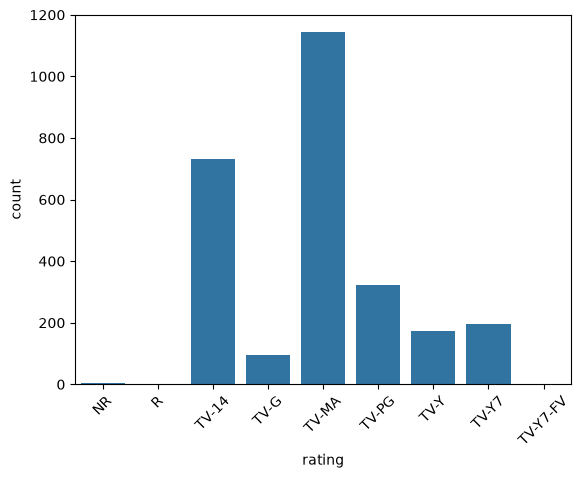

In [137]:
sns.countplot(data=df_tv_rating, x='rating')
plt.xticks(rotation=45)
plt.show()

##### `listed_in`

In [138]:
df_tv_listed_in = df_tv.loc[~df_tv.duplicated(subset=['show_id', 'listed_in'], keep='first')]

In [139]:
len(df_tv_listed_in)

6124

In [140]:
df_tv_listed_in['listed_in'].value_counts(dropna=False)

listed_in
International TV Shows          1349
TV Dramas                        761
TV Comedies                      581
Crime TV Shows                   470
Kids' TV                         449
Docuseries                       395
Romantic TV Shows                370
Reality TV                       255
British TV Shows                 253
Anime Series                     176
Spanish-Language TV Shows        173
TV Action & Adventure            168
Korean TV Shows                  151
TV Mysteries                      98
Science & Nature TV               92
TV Sci-Fi & Fantasy               84
TV Horror                         75
Teen TV Shows                     69
TV Thrillers                      57
Stand-Up Comedy & Talk Shows      56
Classic & Cult TV                 28
TV Shows                          14
Name: count, dtype: int64

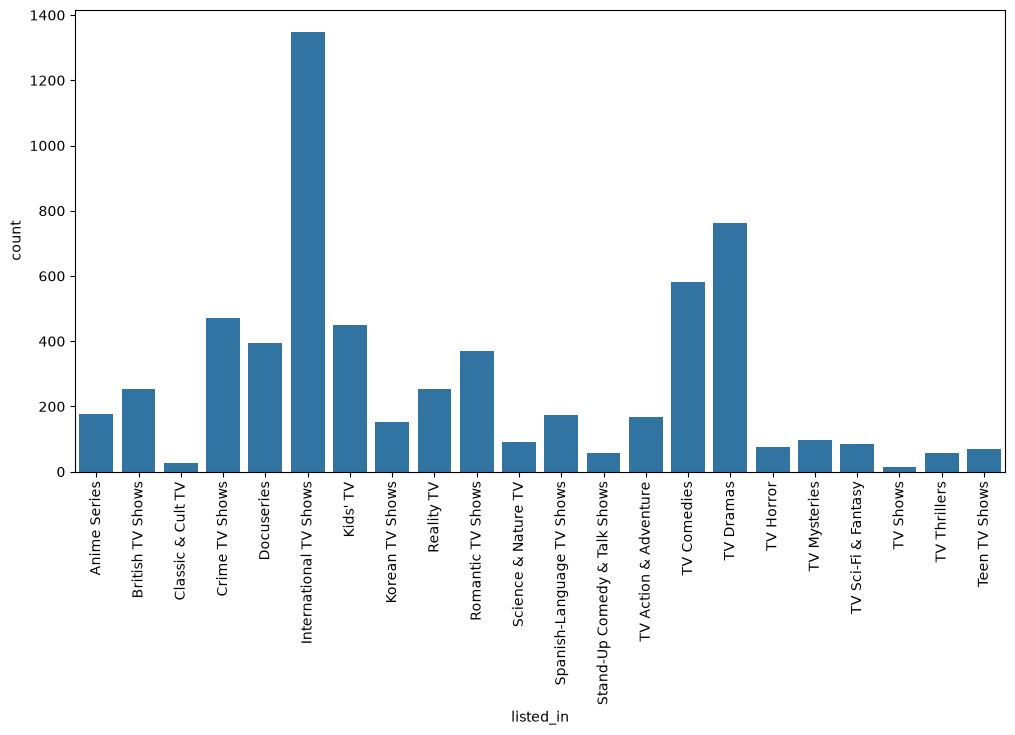

In [141]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_tv_listed_in, x='listed_in')
plt.xticks(rotation=90)
plt.show()

#### Popular times to launch a tv-show

##### Popular week of year

In [142]:
df_tv_week = df_tv.loc[~df_tv.duplicated(subset=['show_id', 'date_added_week'], keep='first')]
len(df_tv_week)

2670

In [143]:
df_tv_week['date_added_week'].value_counts(dropna=False).head(20)

date_added_week
27    86
31    82
24    75
13    75
44    75
35    74
26    73
5     73
40    72
50    70
37    69
18    61
22    60
48    60
1     56
39    55
15    52
52    52
38    51
51    51
Name: count, dtype: Int64

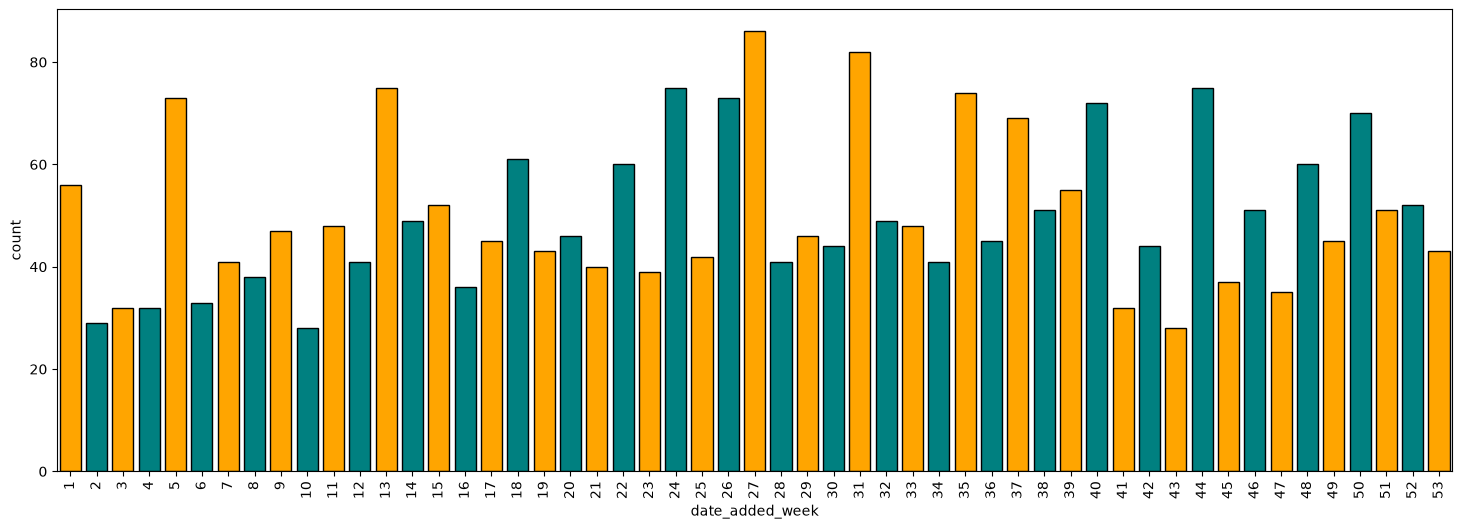

In [144]:
plt.figure(figsize=(18, 6))
ax = sns.countplot(data=df_tv_week, x='date_added_week')
plt.xticks(rotation=90)

colors = ['orange', 'teal']

for i, bar in enumerate(ax.patches):
    bar.set_color(colors[i % len(colors)])
    bar.set_edgecolor('black') 
plt.show()

##### Popular month

In [145]:
df_tv_month = df_tv.loc[~df_tv.duplicated(subset=['show_id', 'date_added_month'], keep='first')]
len(df_tv_month)

2670

In [146]:
df_tv_month['date_added_month'].value_counts(dropna=False)

date_added_month
12.0    266
7.0     261
9.0     251
8.0     236
6.0     236
4.0     214
10.0    214
3.0     211
11.0    207
5.0     192
1.0     191
2.0     181
NaN      10
Name: count, dtype: int64

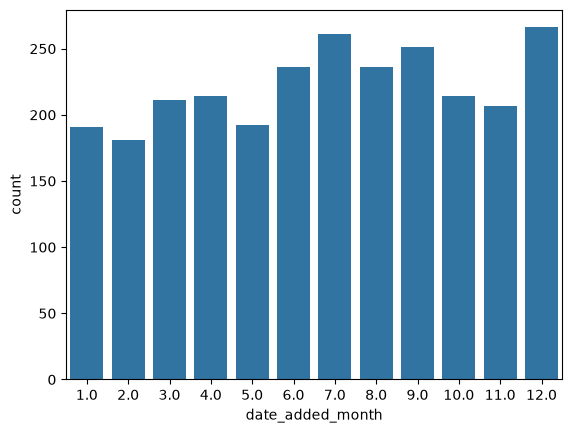

In [147]:
sns.countplot(data=df_tv_month, x='date_added_month')
plt.show()

##### Popular day of week

0 = Monday, 6 = Sunday

In [148]:
df_tv_dow = df_tv.loc[~df_tv.duplicated(subset=['show_id', 'date_added_dayofweek'], keep='first')]
len(df_tv_dow)

2670

In [149]:
df_tv_dow['date_added_dayofweek'].value_counts(dropna=False)

date_added_dayofweek
4.0    930
2.0    380
1.0    344
3.0    343
5.0    258
0.0    223
6.0    182
NaN     10
Name: count, dtype: int64

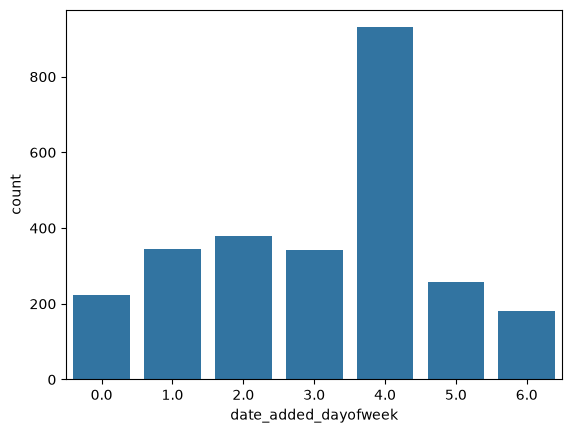

In [150]:
sns.countplot(data=df_tv_dow, x='date_added_dayofweek')
plt.show()

#### Top 10 tv show actors

In [151]:
df_tv_actors = df_tv.loc[~df_tv.duplicated(subset=['show_id', 'cast'])]
df_tv_actors.shape[0]

19960

In [152]:
df_tv_actors['cast'].value_counts(dropna=True).head(10)

cast
Takahiro Sakurai       25
Yuki Kaji              19
Junichi Suwabe         17
Daisuke Ono            17
Ai Kayano              17
Yuichi Nakamura        16
Jun Fukuyama           15
Yoshimasa Hosoya       15
David Attenborough     14
Yoshitsugu Matsuoka    13
Name: count, dtype: int64

#### Top 10 tv show directors

In [153]:
df_tv_directors = df_tv.loc[~df_tv.duplicated(subset=['show_id', 'director'])]
df_tv_directors.shape[0]

2752

In [154]:
df_tv_directors['director'].value_counts(dropna=True).head(10)

director
Alastair Fothergill      3
Ken Burns                3
Gautham Vasudev Menon    2
Hsu Fu-chun              2
Rob Seidenglanz          2
Joe Berlinger            2
Jung-ah Im               2
Lynn Novick              2
Shin Won-ho              2
Stan Lathan              2
Name: count, dtype: int64

#### Gap between `release_date` and `date_added` for tv shows (in years)

In [155]:
tv_shows_unique = df_tv.loc[~df_tv.duplicated(subset=['show_id'], keep='first')]
len(tv_shows_unique)

2670

In [156]:
gaps_in_years = tv_shows_unique['date_added_year'] - tv_shows_unique['release_year']
gaps_in_years.value_counts(dropna=False)

 0.0     1375
 1.0      405
 2.0      223
 3.0      144
 4.0       94
 6.0       70
 5.0       70
 7.0       48
 8.0       38
 9.0       33
 10.0      18
 11.0      16
 14.0      13
 13.0      12
 15.0      11
 12.0      10
-1.0       10
 NaN       10
 16.0       8
 18.0       7
 17.0       6
 27.0       5
 19.0       5
 21.0       5
 20.0       4
 24.0       3
 22.0       3
 25.0       3
 29.0       2
 28.0       2
 76.0       1
 34.0       1
 93.0       1
 46.0       1
 44.0       1
-2.0        1
 23.0       1
 41.0       1
 38.0       1
-3.0        1
 37.0       1
 71.0       1
 31.0       1
 33.0       1
 26.0       1
 50.0       1
 54.0       1
Name: count, dtype: int64

We have few cases where gap is negative, let's exclude these:

In [157]:
valid_gaps_in_years = gaps_in_years[gaps_in_years >= 0]
valid_gaps_in_years.value_counts()

0.0     1375
1.0      405
2.0      223
3.0      144
4.0       94
6.0       70
5.0       70
7.0       48
8.0       38
9.0       33
10.0      18
11.0      16
14.0      13
13.0      12
15.0      11
12.0      10
16.0       8
18.0       7
17.0       6
27.0       5
19.0       5
21.0       5
20.0       4
24.0       3
22.0       3
25.0       3
29.0       2
28.0       2
76.0       1
34.0       1
93.0       1
46.0       1
44.0       1
23.0       1
41.0       1
38.0       1
37.0       1
71.0       1
31.0       1
33.0       1
26.0       1
50.0       1
54.0       1
Name: count, dtype: int64

### Analysis for movies - `df_mov`

In [158]:
df_mov.info()

<class 'pandas.DataFrame'>
Index: 145234 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   show_id               145234 non-null  str           
 1   type                  145234 non-null  category      
 2   title                 145234 non-null  str           
 3   director              143958 non-null  str           
 4   cast                  143915 non-null  str           
 5   country               139177 non-null  str           
 6   date_added            145234 non-null  datetime64[us]
 7   release_year          145234 non-null  int64         
 8   rating                145222 non-null  category      
 9   listed_in             145234 non-null  category      
 10  date_added_year       145234 non-null  float64       
 11  date_added_month      145234 non-null  float64       
 12  date_added_day        145234 non-null  float64       
 13  date_added_week  

#### Categorical variables: `rating`, `listed_in`

##### `rating`

In [159]:
df_mov_rating = df_mov.loc[~df_mov.duplicated(subset=['show_id', 'rating'], keep='first')]
len(df_mov_rating)

6105

In [160]:
df_mov_rating['rating'].value_counts(dropna=False)

rating
TV-MA       2060
TV-14       1409
R            796
TV-PG        539
PG-13        489
PG           286
TV-Y7        139
TV-Y         131
TV-G         125
NR            74
G             41
TV-Y7-FV       5
NaN            5
NC-17          3
UR             3
Name: count, dtype: int64

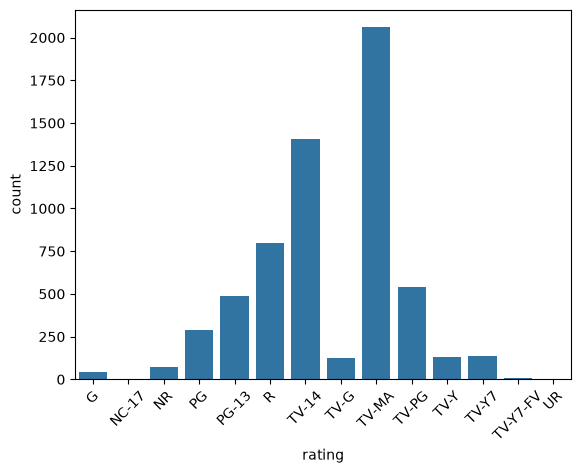

In [161]:
sns.countplot(data=df_mov_rating, x='rating')
plt.xticks(rotation=45)
plt.show()

##### `listed_in`

In [162]:
df_mov_listed_in = df_mov.loc[~df_mov.duplicated(subset=['show_id', 'listed_in'], keep='first')]

In [163]:
len(df_mov_listed_in)

13115

In [164]:
df_mov_listed_in['listed_in'].value_counts(dropna=False)

listed_in
International Movies        2732
Dramas                      2416
Comedies                    1665
Documentaries                869
Action & Adventure           853
Independent Movies           755
Children & Family Movies     639
Romantic Movies              615
Thrillers                    569
Music & Musicals             368
Horror Movies                352
Stand-Up Comedy              343
Sci-Fi & Fantasy             242
Sports Movies                219
Classic Movies               116
LGBTQ Movies                 102
Cult Movies                   70
Anime Features                68
Faith & Spirituality          65
Movies                        57
Name: count, dtype: int64

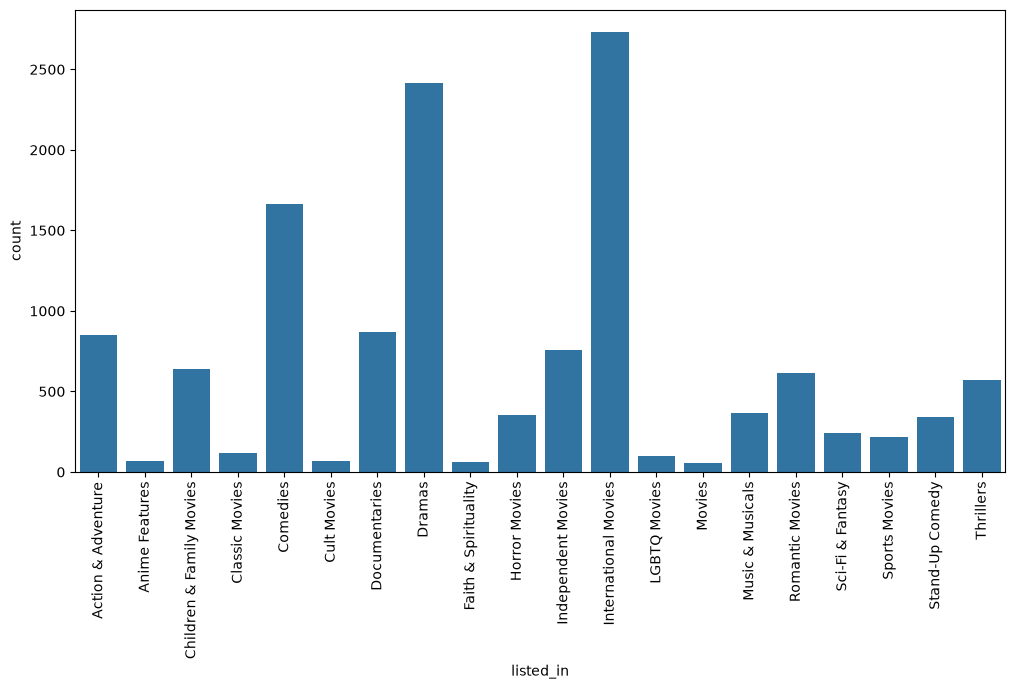

In [165]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_mov_listed_in, x='listed_in')
plt.xticks(rotation=90)
plt.show()

#### Popular times to launch a movie

##### Popular week of year

In [166]:
df_mov_week = df_mov.loc[~df_mov.duplicated(subset=['show_id', 'date_added_week'], keep='first')]
len(df_mov_week)

6105

In [167]:
df_mov_week['date_added_week'].value_counts(dropna=False).head(20)

date_added_week
1     315
44    243
40    215
9     205
26    194
35    186
31    185
13    173
18    172
27    154
22    146
48    138
5     134
16    124
14    123
50    119
30    116
11    115
37    113
23    112
Name: count, dtype: Int64

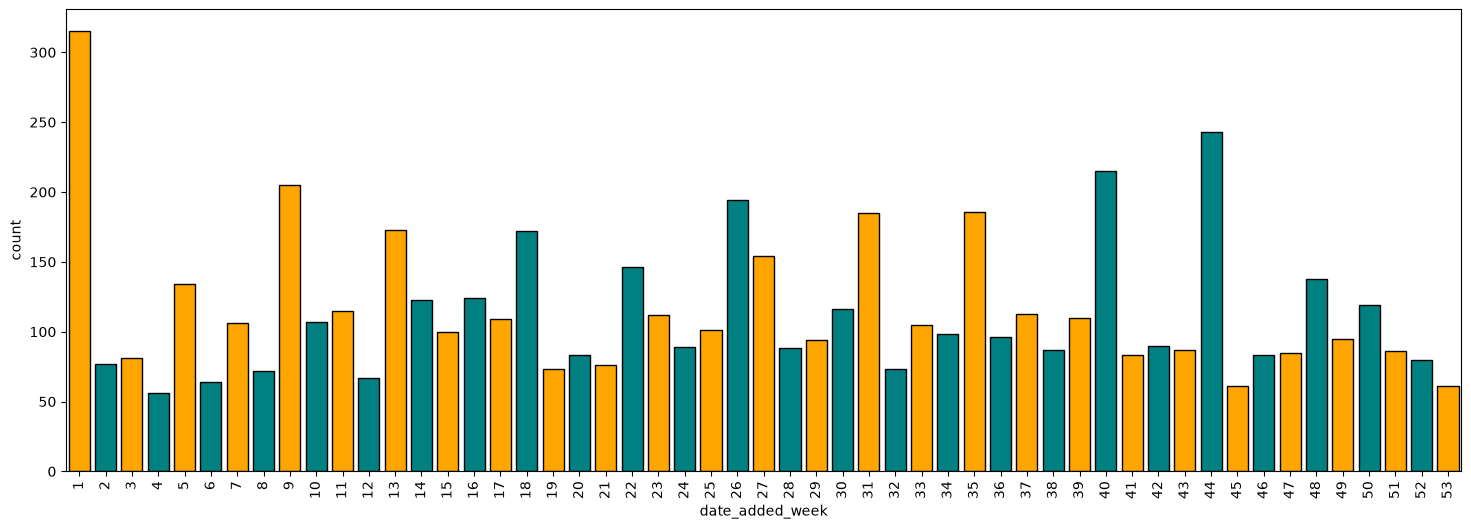

In [168]:
plt.figure(figsize=(18, 6))
ax = sns.countplot(data=df_mov_week, x='date_added_week')
plt.xticks(rotation=90)

colors = ['orange', 'teal']

for i, bar in enumerate(ax.patches):
    bar.set_color(colors[i % len(colors)])
    bar.set_edgecolor('black') 
plt.show()

##### Popular month

In [169]:
df_mov_month = df_mov.loc[~df_mov.duplicated(subset=['show_id', 'date_added_month'], keep='first')]
len(df_mov_month)

6105

In [170]:
df_mov_month['date_added_month'].value_counts(dropna=False)

date_added_month
7.0     564
4.0     549
12.0    547
1.0     543
10.0    543
3.0     527
8.0     515
9.0     512
11.0    497
6.0     491
5.0     436
2.0     381
Name: count, dtype: int64

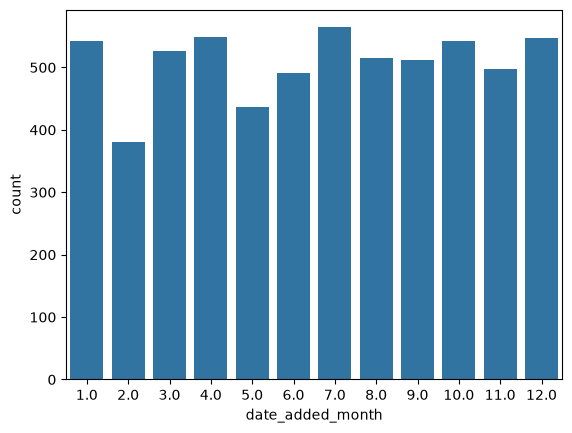

In [171]:
sns.countplot(data=df_mov_month, x='date_added_month')
plt.show()

##### Popular day of week

0 = Monday, 6 = Sunday

In [172]:
df_mov_dow = df_mov.loc[~df_mov.duplicated(subset=['show_id', 'date_added_dayofweek'], keep='first')]
len(df_mov_dow)

6105

In [173]:
df_mov_dow['date_added_dayofweek'].value_counts(dropna=False)

date_added_dayofweek
4.0    1556
3.0    1051
2.0     901
1.0     851
0.0     623
6.0     568
5.0     555
Name: count, dtype: int64

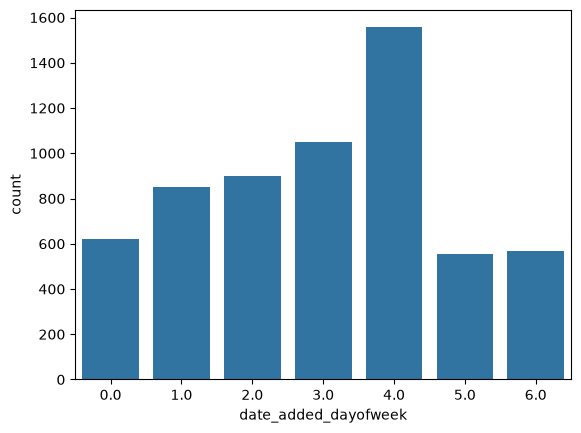

In [174]:
sns.countplot(data=df_mov_dow, x='date_added_dayofweek')
plt.show()

#### Top 10 movie actors

In [175]:
df_mov_actors = df_mov.loc[~df_mov.duplicated(subset=['show_id', 'cast'])]
df_mov_actors.shape[0]

44761

In [176]:
df_mov_actors['cast'].value_counts(dropna=True).head(10)

cast
Anupam Kher         41
Shah Rukh Khan      35
Naseeruddin Shah    32
Akshay Kumar        30
Om Puri             30
Amitabh Bachchan    28
Julie Tejwani       28
Paresh Rawal        28
Rupa Bhimani        27
Boman Irani         27
Name: count, dtype: int64

#### Top 10 movie directors

In [177]:
df_mov_directors = df_mov.loc[~df_mov.duplicated(subset=['show_id', 'director'])]
df_mov_directors.shape[0]

6827

In [178]:
df_mov_directors['director'].value_counts(dropna=True).head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Jay Karas              15
Marcus Raboy           15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

#### Gap between `release_date` and `date_added` for movies (in years)

In [179]:
mov_unique = df_mov.loc[~df_mov.duplicated(subset=['show_id'], keep='first')]
len(mov_unique)

6105

In [180]:
gaps_in_years = mov_unique['date_added_year'] - mov_unique['release_year']
gaps_in_years.value_counts(dropna=False)

 0.0     1848
 1.0     1174
 2.0      491
 3.0      347
 4.0      272
 5.0      190
 6.0      179
 8.0      147
 7.0      139
 9.0      128
 11.0     119
 10.0     117
 12.0      88
 13.0      85
 14.0      62
 16.0      54
 18.0      50
 15.0      47
 17.0      44
 21.0      38
 20.0      35
 22.0      33
 23.0      31
 24.0      29
 19.0      26
 25.0      25
 26.0      22
 27.0      19
 29.0      19
 37.0      16
 28.0      15
 30.0      13
 40.0      13
 38.0      12
 35.0      12
 43.0      11
 34.0      11
 39.0      11
 31.0      10
 41.0      10
 33.0      10
 46.0       9
 32.0       9
 36.0       9
 45.0       8
 49.0       5
 57.0       5
 44.0       5
 47.0       4
 51.0       4
 54.0       4
 42.0       3
 59.0       3
 52.0       3
 72.0       3
 73.0       3
 74.0       3
 62.0       2
 66.0       2
 64.0       2
-1.0        2
 55.0       2
 48.0       2
 61.0       2
 75.0       2
 65.0       2
 60.0       1
 50.0       1
 63.0       1
 71.0       1
 70.0       1
Name: 

We have few cases where gap is negative, let's exclude these:

In [181]:
valid_gaps_in_years = gaps_in_years[gaps_in_years >= 0]
valid_gaps_in_years.value_counts()

0.0     1848
1.0     1174
2.0      491
3.0      347
4.0      272
5.0      190
6.0      179
8.0      147
7.0      139
9.0      128
11.0     119
10.0     117
12.0      88
13.0      85
14.0      62
16.0      54
18.0      50
15.0      47
17.0      44
21.0      38
20.0      35
22.0      33
23.0      31
24.0      29
19.0      26
25.0      25
26.0      22
27.0      19
29.0      19
37.0      16
28.0      15
30.0      13
40.0      13
38.0      12
35.0      12
43.0      11
34.0      11
39.0      11
31.0      10
41.0      10
33.0      10
46.0       9
32.0       9
36.0       9
45.0       8
49.0       5
57.0       5
44.0       5
47.0       4
51.0       4
54.0       4
42.0       3
59.0       3
52.0       3
72.0       3
73.0       3
74.0       3
62.0       2
66.0       2
64.0       2
55.0       2
48.0       2
61.0       2
75.0       2
65.0       2
60.0       1
50.0       1
63.0       1
71.0       1
70.0       1
Name: count, dtype: int64

Similar to the analysis done for tv-shows and movies above, we can do it for top-3 countries for each of tv-shows and movies as well.